# Random Forest Trade Filter
### Meta-labeling layer on top of the EWMA crossover strategy

The EWMA crossing model decides **side** $\{-1, +1\}$.  
This notebook trains a Random Forest to decide **whether to trade at all** $\{0, 1\}$,
i.e., to **meta-label** each crossover event.

Pipeline:
1. Reproduce the crossover events and triple-barrier labels from the primary model.
2. Engineer features that are available **at the time of the event** (no look-ahead).
3. Compute **overlap-uniqueness weights** so the RF loss is not distorted by
   overlapping barrier windows (López de Prado, *AFML* §4).
4. Walk-forward train/test split with an embargo gap.
5. Evaluate with overlap-weighted F1 and plot the equity curves for  
   **All signals** vs **Filtered signals** vs **Buy & Hold**.


In [17]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import (classification_report, precision_score, recall_score, f1_score,
                               ConfusionMatrixDisplay)
from sklearn.utils    import check_random_state

warnings.filterwarnings("ignore")

# ── Load data ──────────────────────────────────────────────────────────────
DATA_PATH = r'G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_dollar_bars.csv'

raw   = pd.read_csv(DATA_PATH)
raw['timestamp'] = pd.to_datetime(raw['timestamp'])
raw   = raw.set_index('timestamp').sort_index()
close = raw['Close'].astype(float)
high  = raw['High'].astype(float)
low   = raw['Low'].astype(float)
volume = raw['Volume'].astype(float) if 'Volume' in raw.columns else None

print(f"Loaded {len(close):,} bars  "
      f"| {close.index[0].date()} → {close.index[-1].date()}")


Loaded 2,048 bars  | 2017-01-11 → 2025-12-30


## 1 — Primary model: EWMA crossover events + triple-barrier labels
Reproduces the labeling from `Trend_Following_Strategy_v2` so this script
is self-contained.


In [32]:
# ── Hyper-parameters (mirror v2) ──────────────────────────────────────────
FAST_SPAN = 3
SLOW_SPAN = 5
BURN_IN   = SLOW_SPAN * 3
NUM_BARS  = 63          # vertical barrier
PT_SL     = [1.0, 1.0]  # symmetric barriers
MIN_RET   = 0.001
VOL_SPAN  = 20

# ── EWMA crossover events ─────────────────────────────────────────────────
def get_crossover_events(close, fast_span=FAST_SPAN, slow_span=SLOW_SPAN,
                         burn_in=BURN_IN):
    fast = close.ewm(span=fast_span, adjust=False).mean()
    slow = close.ewm(span=slow_span, adjust=False).mean()
    fast, slow = fast.iloc[burn_in:], slow.iloc[burn_in:]
    diff = fast - slow
    bullish = (diff.shift(1) <= 0) & (diff > 0)
    bearish = (diff.shift(1) >= 0) & (diff < 0)
    df = pd.DataFrame({'fast_ewma': fast, 'slow_ewma': slow})
    df['side'] = np.where(bullish, 1, np.where(bearish, -1, 0))
    return df[df['side'] != 0].copy()

events_cross = get_crossover_events(close)
print(f"Crossover events: {len(events_cross)} "
      f"(bull={( events_cross['side']==1).sum()}, "
      f"bear={(events_cross['side']==-1).sum()})")


Crossover events: 312 (bull=156, bear=156)


In [33]:
vol_20 = close.pct_change().ewm(span=20, adjust=False).std()
print(f"mean vol_20: {vol_20.mean():.4f}  |  std vol_20: {vol_20.std():.4f}") 
print(f"max vol_20: {vol_20.max():.4f}  |  min vol_20: {vol_20.min():.4f}")

mean vol_20: 0.0100  |  std vol_20: 0.0051
max vol_20: 0.0359  |  min vol_20: 0.0025


In [34]:
def _apply_barriers(close, events, pt_sl):
    """Return DataFrame(pt, sl) — first time each barrier is touched."""
    # Prepare an output DataFrame indexed by event entry times with two
    # columns: 'pt' (profit-taking touch time) and 'sl' (stop-loss touch time).
    out = pd.DataFrame(index=events.index,
                       columns=['pt', 'sl'],
                       dtype='datetime64[ns]')
    # Iterate over labeled events; 'loc' is the event timestamp (entry).
    for loc, ev in events.iterrows():
        try:
            # Find the integer location of the event in the price index.
            lp = close.index.get_loc(loc)
        except KeyError:
            # If the event timestamp is not present in the price index, skip.
            continue
        # Determine the index position of the vertical barrier (t1).
        ep = close.index.get_indexer(
            [ev['t1'] if pd.notna(ev['t1']) else close.index[-1]],
            method='bfill')[0]
        # Start checking from the next bar after the entry.
        sp = lp + 1
        # If the entry is after the barrier, nothing to check.
        if sp > ep:
            continue
        # Extract the price path between entry+1 and the barrier (inclusive).
        path = close.iloc[sp: ep + 1]
        # Need at least two bars (entry reference + one subsequent bar) to compute returns.
        if len(path) < 2:
            continue
        # Compute returns relative to the first bar in the path, then align to the
        # signal direction by multiplying by ev['side'] (+1/-1).
        rets = (path.iloc[1:] / path.iloc[0] - 1.0) * ev['side']
        # Profit-taking: first time return >= pt threshold * target volatility.
        if pt_sl[0] > 0:
            hit = rets[rets >=  pt_sl[0] * ev['trgt']]
            if not hit.empty:
                # Record the timestamp of the first hit (earliest index in hit).
                out.loc[loc, 'pt'] = hit.index[0]
        # Stop-loss: first time return <= -sl threshold * target volatility.
        if pt_sl[1] > 0:
            hit = rets[rets <= -pt_sl[1] * ev['trgt']]
            if not hit.empty:
                out.loc[loc, 'sl'] = hit.index[0]
    # Ensure returned timestamps are proper datetimes (NaT preserved where no hit).
    out['pt'] = pd.to_datetime(out['pt'])
    out['sl'] = pd.to_datetime(out['sl'])
    return out


def get_labeled_events(close, events_cross, pt_sl, vol_span,
                       min_ret, num_bars):
    """
    Build the canonical labeled-event table.

    Returns columns: t1, trgt, side, t_hit, label
        label = +1 (PT hit)
                -1 (SL hit)
                 0 (vertical barrier / timeout)
    """
    # All event timestamps from the crossover detector
    tEvents = events_cross.index
    # Target (trgt) is the EWM standard deviation of 1-bar returns (volatility estimate).
    trgt    = 5 * close.pct_change().ewm(span=vol_span, adjust=False).std()
    # Keep only targets for times where we actually had events; drop NaNs.
    trgt    = trgt.reindex(tEvents).dropna()
    # Discard events whose volatility target is too small (filter by min_ret).
    trgt    = trgt[trgt > min_ret]

    # Vertical barrier: map each event to its barrier timestamp (num_bars ahead).
    pos = close.index.get_indexer(trgt.index, method='backfill')
    barrier_pos = np.minimum(pos + num_bars, len(close) - 1)
    t1 = pd.Series(close.index[barrier_pos], index=trgt.index)

    # Build base event table with t1 and volatility target
    ev = pd.DataFrame({'t1': t1, 'trgt': trgt})
    # Attach the EWMA side signal (+1/-1) to each event (reindex to align).
    ev['side'] = events_cross['side'].reindex(ev.index).astype(float)

    # Find first touch times for pt/sl within each event window.
    hits = _apply_barriers(close, ev, pt_sl)

    # Combine the vertical-barrier time with any pt/sl hit times so we can
    # compute the earliest time that ended the event (t_hit).
    cand = pd.concat([ev['t1'], hits['pt'], hits['sl']], axis=1)
    cand.columns = ['t1', 'pt', 'sl']
    # Stack columns to a single Series per event and take the earliest timestamp.
    ev['t_hit'] = cand.stack(dropna=True).groupby(level=0).min()

    # Determine label: +1 if PT occurred in signal direction, -1 if SL occurred
    # (opposite direction), 0 otherwise (should include vertical/timeouts).
    def _label(row):
        if pd.isna(row['t_hit']):
            return 0
        # If profit-taking timestamp exists and is the one that ended the event,
        # label according to the signal side (correct trade).
        if pd.notna(hits.loc[row.name, 'pt']) and row['t_hit'] == hits.loc[row.name, 'pt']:
            return int(row['side'])
        # If stop-loss timestamp exists and ended the event, label opposite sign.
        if pd.notna(hits.loc[row.name, 'sl']) and row['t_hit'] == hits.loc[row.name, 'sl']:
            return -int(row['side'])
        return 0

    ev['label'] = ev.apply(_label, axis=1)
    ev['meta_label'] = (ev['label'] * ev['side'] > 0).astype(int)
    return ev


labeled = get_labeled_events(close, events_cross,
                             PT_SL, VOL_SPAN, MIN_RET, NUM_BARS)
print(f"Labeled events : {len(labeled)}")
print(labeled['label'].value_counts()
      .rename({1:'PT (+1)', -1:'SL (-1)', 0:'Vertical (0)'}))


Labeled events : 312
label
PT (+1)         203
SL (-1)          80
Vertical (0)     29
Name: count, dtype: int64


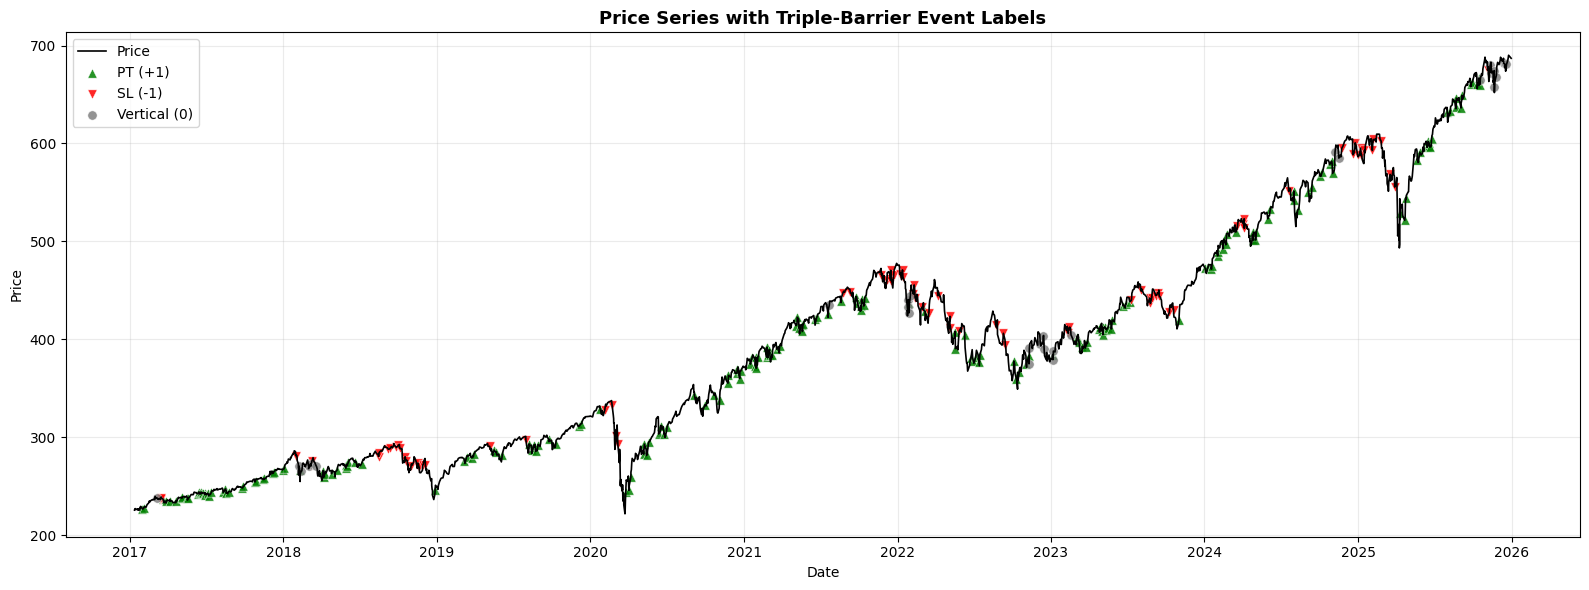

In [35]:
# Price series with event labels
label_styles = {
    1:  {'color': 'green',  'marker': '^', 'label': 'PT (+1)'},
    -1: {'color': 'red',    'marker': 'v', 'label': 'SL (-1)'},
    0:  {'color': 'gray',   'marker': 'o', 'label': 'Vertical (0)'},
}

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(close.index, close.values, color='black', linewidth=1.2, label='Price')

for lbl, style in label_styles.items():
    ev = labeled[labeled['label'] == lbl]
    if ev.empty:
        continue
    ax.scatter(
        ev.index,
        close.reindex(ev.index),
        s=45,
        alpha=0.85,
        c=style['color'],
        marker=style['marker'],
        label=style['label'],
        edgecolors='white',
        linewidths=0.4,
    )

ax.set_title('Price Series with Triple-Barrier Event Labels', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

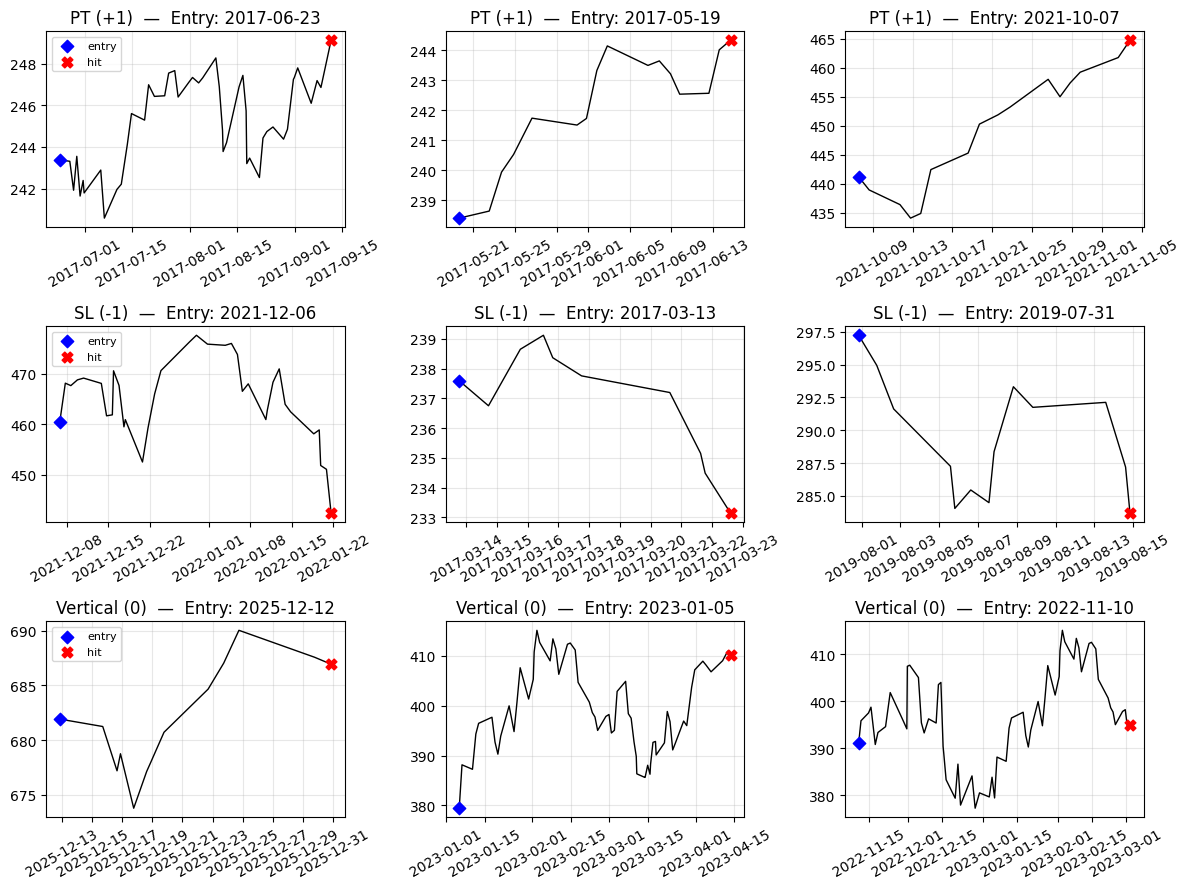

In [36]:
# Plot examples of each label (few sample events per label)
import random

n_examples = 3
label_order = [1, -1, 0]  # PT, SL, Vertical
label_names = {1: 'PT (+1)', -1: 'SL (-1)', 0: 'Vertical (0)'}

# Prepare subplot grid
n_rows = len(label_order)
fig, axes = plt.subplots(n_rows, n_examples, figsize=(4 * n_examples, 3 * n_rows), squeeze=False)

for i, lbl in enumerate(label_order):
    evs = labeled[labeled['label'] == lbl]
    if evs.empty:
        for j in range(n_examples):
            axes[i, j].axis('off')
        continue

    # deterministic sampling if below n_examples use head, else sample
    if len(evs) <= n_examples:
        samples = evs.iloc[:n_examples]
    else:
        samples = evs.sample(n=n_examples, random_state=42)

    for j in range(n_examples):
        ax = axes[i, j]
        try:
            ts = samples.index[j]
            row = samples.iloc[j]
        except Exception:
            ax.axis('off')
            continue

        # Define start (entry) and end (hit or vertical barrier)
        start = ts
        end = row.get('t_hit') if pd.notna(row.get('t_hit')) else row.get('t1')
        # If end is NaT or before start, extend a small window after start
        if pd.isna(end) or end <= start:
            # choose a small horizon of NUM_BARS or 10 bars
            end_pos = min(close.index.get_loc(start) + min(NUM_BARS, 10), len(close) - 1)
            end = close.index[end_pos]

        path = close.loc[start:end]
        if path.empty:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center')
            ax.set_title(f"{label_names[lbl]}\nEntry: {start.date()}")
            ax.grid(False)
            continue

        ax.plot(path.index, path.values, color='black', lw=1.0)
        # mark entry
        if start in close.index:
            ax.scatter([start], [close.loc[start]], marker='D', color='blue', s=40, zorder=5, label='entry')
        # mark hit if exists
        if pd.notna(row.get('t_hit')) and row.get('t_hit') in close.index:
            ax.scatter([row.get('t_hit')], [close.loc[row.get('t_hit')]], marker='X', color='red', s=60, zorder=6, label='hit')

        ax.set_title(f"{label_names[lbl]}  —  Entry: {start.date()}")
        ax.xaxis.set_tick_params(rotation=30)
        ax.grid(True, alpha=0.3)

# Clean up legends (one per row)
for i in range(n_rows):
    axes[i, 0].legend(loc='upper left', fontsize=8)
    for j in range(1, n_examples):
        axes[i, j].legend_.remove() if getattr(axes[i, j], 'legend_', None) else None

plt.tight_layout()
plt.show()

In [37]:
# Basic statistics per triple-barrier label
import numpy as np

rows = []
for lbl in [1, -1, 0]:
    ev = labeled[labeled['label'] == lbl].copy()
    if ev.empty:
        rows.append({
            'Label': lbl,
            'Count': 0,
        })
        continue

    entries = ev.index
    ends = ev['t_hit'].fillna(ev['t1'])

    # Map to integer positions for bar-count duration
    entry_pos = close.index.get_indexer(entries, method='bfill')
    end_pos   = close.index.get_indexer(ends,    method='bfill')
    duration_bars = (end_pos - entry_pos).astype(float)

    # Duration in days (wall-clock) as float
    duration_days = ((ends - entries) / pd.Timedelta(days=1)).astype(float)

    # Prices at entry and end (may contain NaN if index mismatch)
    p_entry = close.reindex(entries).values
    p_end   = close.reindex(ends).values

    # Raw return (end / start - 1)
    with np.errstate(divide='ignore', invalid='ignore'):
        raw_ret = (p_end / p_entry - 1.0)
    # Align to the signal direction: signed return = raw_ret * side
    side_arr = ev['side'].astype(float).values
    signed_ret = raw_ret * side_arr
    abs_ret = np.abs(raw_ret)

    # Metrics
    count = len(ev)
    pct_t_hit_missing = ev['t_hit'].isna().mean()

    row = {
        'Label': lbl,
        'Count': int(count),
        'Pct missing t_hit': float(pct_t_hit_missing),
        'Mean duration (bars)': float(np.nanmean(duration_bars)),
        'Median duration (bars)': float(np.nanmedian(duration_bars)),
        'Mean duration (days)': float(np.nanmean(duration_days)),
        'Mean signed return': float(np.nanmean(signed_ret)),
        'Median signed return': float(np.nanmedian(signed_ret)),
        'Std signed return': float(np.nanstd(signed_ret, ddof=0)),
        'Mean abs return': float(np.nanmean(abs_ret)),
        'Median abs return': float(np.nanmedian(abs_ret)),
        'Std abs return': float(np.nanstd(abs_ret, ddof=0)),
        'Win rate (signed>0)': float(np.nanmean(signed_ret > 0)),
    }
    rows.append(row)

stats_df = pd.DataFrame(rows).set_index('Label')

# Nicely format label names
label_map = {1: 'PT (+1)', -1: 'SL (-1)', 0: 'Vertical (0)'}
stats_df.index = stats_df.index.map(lambda x: label_map.get(x, str(x)))

# Display rounded table
print('\nLabel statistics (entry → hit / t1):')
print(stats_df.round(6).to_string())

# Add some distribution percentiles for durations and returns (for PT/SL rows only)
for lbl in [1, -1]:
    ev = labeled[labeled['label'] == lbl].copy()
    if ev.empty:
        continue
    entries = ev.index
    ends = ev['t_hit'].fillna(ev['t1'])
    p_entry = close.reindex(entries).values
    p_end   = close.reindex(ends).values
    with np.errstate(divide='ignore', invalid='ignore'):
        raw_ret = (p_end / p_entry - 1.0)
    side_arr = ev['side'].astype(float).values
    signed_ret = raw_ret * side_arr

    print(f"\nDistribution for label {label_map[lbl]} (signed returns)")
    print(pd.Series(signed_ret).dropna().quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_string())

# Mark todo done
from datetime import datetime
print(f"\nComputed at {datetime.utcnow().isoformat()} UTC")


Label statistics (entry → hit / t1):
              Count  Pct missing t_hit  Mean duration (bars)  Median duration (bars)  Mean duration (days)  Mean signed return  Median signed return  Std signed return  Mean abs return  Median abs return  Std abs return  Win rate (signed>0)
Label                                                                                                                                                                                                                                           
PT (+1)         203                0.0             25.798030                    22.0             45.877980            0.003384              0.016880           0.067401         0.058479           0.051217        0.033684             0.512315
SL (-1)          80                0.0             20.475000                    16.0             30.339306            0.003253              0.033249           0.059133         0.054744           0.051720        0.022592             0.53750

## 2 — Meta-labels  $y \in \{0, 1\}$

The RF target is:

$$y_i = \mathbf{1}[\ell_i \cdot s_i > 0]$$

where $\ell_i \in \{-1, 0, +1\}$ is the triple-barrier label and
$s_i \in \{-1, +1\}$ is the EWMA side.  
$y_i = 1$ means "the crossover signal was correct — trade it";  
$y_i = 0$ means "the primary model was wrong or inconclusive — skip it."

Vertical-barrier events ($\ell_i = 0$) are mapped to $y_i = 0$ (do not trade).


In [38]:
# y = 1  iff the primary model's side was correct (PT hit in the signal direction)
labeled['meta_label'] = (labeled['label'] * labeled['side'] > 0).astype(int)

print("Meta-label distribution:")
print(labeled['meta_label'].value_counts().rename({1:'Trade (1)', 0:'Skip (0)'}))
print(f"  Positive rate: {labeled['meta_label'].mean():.3f}")


Meta-label distribution:
meta_label
Skip (0)     165
Trade (1)    147
Name: count, dtype: int64
  Positive rate: 0.471



Example of label 1:
t1            2017-07-10 13:03:00
trgt                     0.021608
side                         -1.0
t_hit         2017-05-15 20:49:00
label                           1
meta_label                      0
Name: 2017-04-06 13:34:00, dtype: object

Example of label -1:
t1            2018-07-11 16:55:00
trgt                     0.057405
side                         -1.0
t_hit         2018-04-02 19:25:00
label                          -1
meta_label                      1
Name: 2018-03-07 18:19:00, dtype: object

Example of label 0:
t1            2018-07-09 19:00:00
trgt                     0.058453
side                          1.0
t_hit         2018-07-09 19:00:00
label                           0
meta_label                      0
Name: 2018-03-06 14:34:00, dtype: object


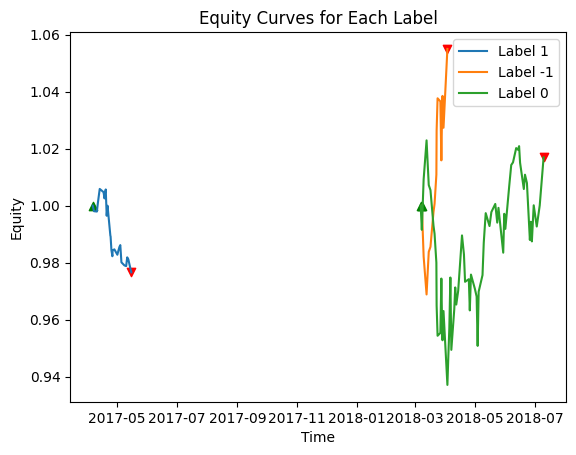

In [39]:
# Show one example of each label and plot its equity curve safely
for lbl in [1, -1, 0]:
    ev = labeled[labeled['label'] == lbl]
    if ev.empty:
        print(f"\nNo events found for label {lbl}")
        continue

    # Pick a stable example index without assuming there are at least 5 rows.
    example = ev.iloc[min(4, len(ev) - 1)]
    print(f"\nExample of label {lbl}:\n{example}")

    start = example.name
    end = example['t_hit'] if pd.notna(example['t_hit']) else example['t1']
    path = close.loc[start:end]

    if len(path) > 1:
        equity_curve = (1 + example['side'] * path.pct_change().fillna(0)).cumprod()
        plt.plot(equity_curve.index, equity_curve.values, label=f'Label {lbl}')
        plt.scatter(start, 1.0, color='green', marker='^')
        if pd.notna(example['t_hit']) and example['t_hit'] in equity_curve.index:
            plt.scatter(example['t_hit'], equity_curve.loc[example['t_hit']], color='red', marker='v')

plt.xlabel('Time')
plt.ylabel('Equity')
plt.title('Equity Curves for Each Label')
plt.legend()
plt.show()

## 3 — Feature engineering

All features are computed **strictly from information available at the event
timestamp** $t_i$, using a look-back window that ends at $t_i$ (never forward).

| Feature | Description |
|---------|-------------|
| `ret_1`, `ret_5`, `ret_20` | Log-returns over past 1, 5, 20 bars |
| `vol_20` | Realized volatility (EWM std of 1-bar returns, span=20) |
| `vol_ratio` | `vol_5 / vol_20` — vol regime indicator |
| `ewma_gap` | Normalized distance between fast and slow EWMA: $(m_f - m_s)/P$ |
| `rsi_14` | Relative Strength Index, 14 bars |
| `bb_pct` | Bollinger %B: position within $[\mu \pm 2\sigma]_{20}$ |
| `side` | EWMA signal direction $\{-1, +1\}$ (the primary model output) |


In [40]:
def build_features(close, events_cross, fast_span=FAST_SPAN,
                   slow_span=SLOW_SPAN):
    """
    Compute features at each event timestamp using only look-back information.

    All rolling/EWM computations are performed on the full price series first;
    then we simply index into the result at event timestamps — no forward bias.
    """
    log_ret = np.log(close / close.shift(1))

    # ── Returns ──────────────────────────────────────────────────────────────
    ret_1  = log_ret
    ret_5  = log_ret.rolling(5).sum()
    ret_20 = log_ret.rolling(20).sum()

    # ── Volatility ───────────────────────────────────────────────────────────
    vol_5  = log_ret.ewm(span=5,  adjust=False).std()
    vol_20 = log_ret.ewm(span=20, adjust=False).std()
    vol_ratio = (vol_5 / vol_20).replace([np.inf, -np.inf], np.nan)

    # ── EWMA gap (normalized) ─────────────────────────────────────────────────
    fast   = close.ewm(span=fast_span, adjust=False).mean()
    slow   = close.ewm(span=slow_span, adjust=False).mean()
    ewma_gap = (fast - slow) / close

    # ── RSI (14) ──────────────────────────────────────────────────────────────
    delta  = close.diff()
    gain   = delta.clip(lower=0).ewm(span=14, adjust=False).mean()
    loss   = (-delta.clip(upper=0)).ewm(span=14, adjust=False).mean()
    rs     = gain / loss.replace(0, np.nan)
    rsi_14 = 100 - 100 / (1 + rs)

    # ── Bollinger %B (20, 2σ) ─────────────────────────────────────────────────
    bb_mid   = close.rolling(50).mean()
    bb_std   = close.rolling(50).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    # bb_pct   = (close - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)
    bb_pct = (close - bb_mid)/(2*bb_std)

    # ── Assemble at event timestamps ──────────────────────────────────────────
    idx = events_cross.index
    X = pd.DataFrame({
        'ret_1'    : ret_1.reindex(idx),
        'ret_5'    : ret_5.reindex(idx),
        'ret_20'   : ret_20.reindex(idx),
        'vol_20'   : vol_20.reindex(idx),
        'vol_ratio': vol_ratio.reindex(idx),
        'ewma_gap' : ewma_gap.reindex(idx),
        'rsi_14'   : rsi_14.reindex(idx),
        'bb_pct'   : bb_pct.reindex(idx),
        'side'     : events_cross['side'].astype(float),
    }, index=idx)

    return X


X_all = build_features(close, events_cross)

# Trailing standardization: standardize each row using only data available up to that point
# (expanding window to prevent look-ahead bias)
X_all_mean = X_all.expanding().mean()
X_all_std = X_all.expanding().std()
X_all = (X_all - X_all_mean) / X_all_std

# Align to labeled events and drop rows with NaN features
X_all = X_all.reindex(labeled.index)
mask  = X_all.notna().all(axis=1)
X_all = X_all[mask]
y_all = labeled.loc[mask, 'meta_label']

print(f"Feature matrix : {X_all.shape}")
print(f"NaN rows dropped: {(~mask).sum()}")
print(X_all.describe().round(4))

Feature matrix : (309, 9)
NaN rows dropped: 3
          ret_1     ret_5    ret_20    vol_20  vol_ratio  ewma_gap    rsi_14  \
count  309.0000  309.0000  309.0000  309.0000   309.0000  309.0000  309.0000   
mean     0.0280    0.0338   -0.0355    0.4351     0.0148    0.0316   -0.0396   
std      1.1821    1.1651    1.1741    1.1135     0.9636    1.2030    1.0077   
min     -3.8110   -4.0082   -3.9004   -1.2541    -2.5492   -5.0795   -2.5224   
25%     -0.9093   -0.6059   -0.6934   -0.3865    -0.6200   -0.6649   -0.7536   
50%      0.0561   -0.0483    0.1156    0.1743     0.0142   -0.0200   -0.0338   
75%      0.8381    0.6364    0.7556    1.0974     0.6690    0.6873    0.6767   
max      3.9479    4.1288    4.3665    5.7145     2.1414    4.9582    2.2702   

         bb_pct      side  
count  309.0000  309.0000  
mean    -0.1026    0.0097  
std      1.0395    0.9879  
min     -2.7700   -0.9952  
25%     -0.8959   -0.9905  
50%      0.1980    0.8660  
75%      0.7159    0.9968  
max      

## 4 — Overlap uniqueness weights

Overlapping barrier windows violate the i.i.d. assumption that underpins
most learning algorithms.  Following López de Prado (*AFML* §4.3) we weight
each sample by the fraction of its barrier window $[t_i, t_i^{\text{hit}}]$
that is not covered by any other active event:

$$w_i = \frac{1}{|\mathcal{W}_i|} \sum_{t \in [t_i, t_i^{\text{hit}}]} \frac{1}{c_t}$$

where $c_t = \sum_j \mathbf{1}[t_j \le t \le t_j^{\text{hit}}]$ is the
concurrent-event count at bar $t$ and $\mathcal{W}_i$ is the number of
bars in the window.  
We use the bar-level approximation below (no intra-bar granularity needed).


In [41]:
def compute_sample_weights(labeled: pd.DataFrame,
                           close_index: pd.Index) -> pd.Series:
    """
    Compute average-uniqueness sample weights for each labeled event.

    Parameters
    ----------
    labeled : DataFrame with columns t_hit (and index = event entry time)
    close_index : full price DatetimeIndex

    Returns
    -------
    pd.Series of weights in (0, 1], indexed like labeled.
    """
    ev = labeled[['t_hit']].dropna(subset=['t_hit']).copy()
    ev['t_hit'] = pd.to_datetime(ev['t_hit'])

    # For each bar in the price index, count how many events are active.
    n_bars = len(close_index)
    concurrent = np.zeros(n_bars, dtype=np.float32)

    entry_pos = close_index.get_indexer(ev.index,    method='bfill')
    exit_pos  = close_index.get_indexer(ev['t_hit'], method='bfill')

    for ep, xp in zip(entry_pos, exit_pos):
        if ep == -1:
            continue
        xp = min(xp if xp != -1 else n_bars - 1, n_bars - 1)
        concurrent[ep: xp + 1] += 1.0

    # Average uniqueness per event = mean of 1/c_t over its window.
    weights = []
    for (ts, row), ep, xp in zip(ev.iterrows(), entry_pos, exit_pos):
        if ep == -1:
            weights.append(1.0)
            continue
        xp = min(xp if xp != -1 else n_bars - 1, n_bars - 1)
        c  = concurrent[ep: xp + 1]
        c  = np.where(c > 0, c, 1.0)
        weights.append(float(np.mean(1.0 / c)))

    return pd.Series(weights, index=ev.index, name='weight')


# Align weights to the filtered feature matrix
weights_all = compute_sample_weights(labeled, close.index)
weights_all = weights_all.reindex(X_all.index).fillna(1.0)

print(f"Sample weights — mean: {weights_all.mean():.4f}  "
      f"| min: {weights_all.min():.4f}  "
      f"| max: {weights_all.max():.4f}")


Sample weights — mean: 0.2396  | min: 0.0796  | max: 1.0000


## 5 — Walk-forward evaluation with embargo

The data are split 70 / 30 (train / test) **in chronological order**.  
An embargo of `EMBARGO_BARS` is removed from the boundary to prevent
information leakage through overlapping barrier windows.

No hyper-parameter search is performed here — the RF is intentionally
kept simple (moderate depth, balanced class weights) to resist overfitting
on small event samples.


In [42]:
TRAIN_FRAC    = 0.70
EMBARGO_BARS  = 0 #NUM_BARS   # same width as the vertical barrier
RANDOM_STATE  = 42

n_events = len(X_all)
n_train  = int(n_events * TRAIN_FRAC)

# Identify the last training event boundary using only timestamps that still exist
# in the labeled table. X_all can contain rows that were dropped when labels were
# created, so a direct .loc lookup can raise KeyError.
train_idx = X_all.index[:n_train]
train_labeled = labeled.reindex(train_idx)
last_t1 = train_labeled['t_hit'].max()

# Fallback: if all t_hit values are missing in the training slice, use the last
# available vertical barrier time instead of failing.
if pd.isna(last_t1):
    last_t1 = train_labeled['t1'].max()

# Embargo: drop events whose entry falls within EMBARGO_BARS of last_t1.
last_bar_pos = close.index.get_indexer([last_t1], method='bfill')[0]
embargo_end  = close.index[min(last_bar_pos + EMBARGO_BARS, len(close) - 1)]

test_idx = X_all.index[X_all.index > embargo_end]

X_train, y_train, w_train = (X_all.loc[train_idx],
                              y_all.loc[train_idx],
                              weights_all.loc[train_idx])
X_test,  y_test,  w_test  = (X_all.loc[test_idx],
                              y_all.loc[test_idx],
                              weights_all.loc[test_idx])

print(f"Train events : {len(X_train)}  ({train_idx[0].date()} → {train_idx[-1].date()})")
print(f"Embargo ends : {embargo_end.date()}")
print(f"Test events  : {len(X_test)}  ({test_idx[0].date()} → {test_idx[-1].date()})")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

# ── Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators     = 200,      # more trees → better performance (up to a point)
    max_depth        = 3,        # shallow → low variance
    min_weight_fraction_leaf= 0.01,        # floor on leaf size given small event counts
    max_features     = 'sqrt',
    class_weight     = 'balanced_subsample',
    n_jobs           = -1,
    random_state     = RANDOM_STATE,
)

rf.fit(X_train, y_train, sample_weight=w_train)
print("\nRandom Forest trained.")

Train events : 216  (2017-03-13 → 2023-05-24)
Embargo ends : 2023-06-13
Test events  : 92  (2023-06-21 → 2025-12-19)
Train positive rate: 0.477
Test  positive rate: 0.457

Random Forest trained.


In [43]:
# Calculate the number of parameters in the Random Forest

n_trees = rf.n_estimators
n_features = rf.n_features_in_
max_depth = rf.max_depth

# Estimate nodes per tree (approximate for a balanced tree)
# Maximum nodes in a tree of depth d: 2^(d+1) - 1
max_nodes_per_tree = 2 ** (max_depth + 1) - 1

# Total parameters: each node has a split threshold + feature index
# Rough estimate: nodes * (1 feature index + 1 threshold) per node
params_per_tree = max_nodes_per_tree * 2

total_params_estimate = n_trees * params_per_tree

print(f"Random Forest Model Complexity")
print(f"=" * 50)
print(f"Number of trees: {n_trees}")
print(f"Number of features: {n_features}")
print(f"Max depth per tree: {max_depth}")
print(f"Max nodes per tree: {max_nodes_per_tree}")
print(f"Parameters per tree (estimate): {params_per_tree}")
print(f"Total parameters (estimate): {total_params_estimate:,}")
print(f"\nActual leaf count (trained trees):")

# Count actual nodes/leaves in trained trees
total_actual_leaves = sum(tree.tree_.node_count for tree in rf.estimators_)
print(f"Total nodes across all trees: {total_actual_leaves:,}")
print(f"Average nodes per tree: {total_actual_leaves / n_trees:.0f}")

Random Forest Model Complexity
Number of trees: 200
Number of features: 9
Max depth per tree: 3
Max nodes per tree: 15
Parameters per tree (estimate): 30
Total parameters (estimate): 6,000

Actual leaf count (trained trees):
Total nodes across all trees: 2,690
Average nodes per tree: 13


## 6 — Evaluation


Meta-label classifier — weighted precision / recall / F1
               Precision  Recall     F1
Model                                  
RF train          0.7403  0.7476 0.7439
RF test           0.6713  0.6736 0.6725
Primary train     0.5095  1.0000 0.6750
Primary test      0.4929  1.0000 0.6603

Comparison on test set (RF - primary)
  Precision delta: +0.1784
  Recall delta   : -0.3264
  F1 delta       : +0.0121

── Test set report (unweighted) ──
              precision    recall  f1-score   support

    Skip (0)       0.68      0.64      0.66        50
   Trade (1)       0.60      0.64      0.62        42

    accuracy                           0.64        92
   macro avg       0.64      0.64      0.64        92
weighted avg       0.64      0.64      0.64        92



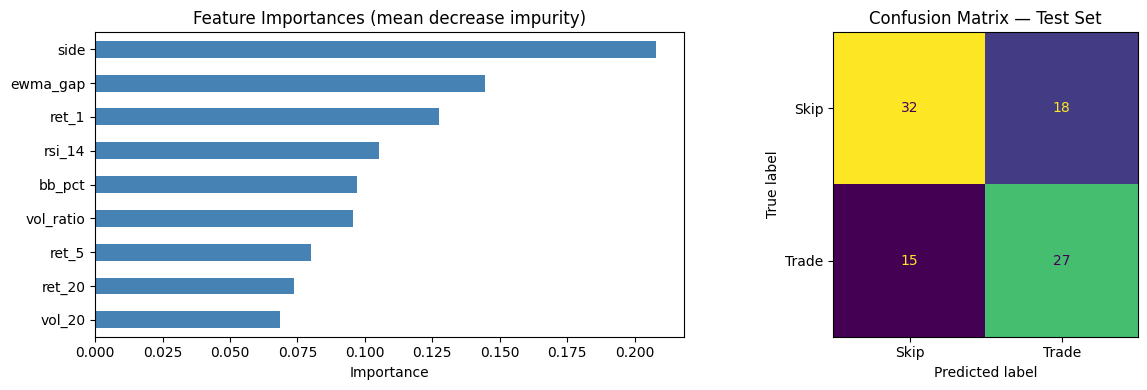

In [44]:
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

# Primary model baseline: always take the trade (predict class 1 for every event)
y_pred_train_primary = np.ones_like(y_train, dtype=int)
y_pred_test_primary  = np.ones_like(y_test, dtype=int)

from sklearn.metrics import precision_score, recall_score

def weighted_metrics(y_true, y_pred, weights):
    return {
        'Precision': precision_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        'Recall': recall_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        'F1': f1_score(y_true, y_pred, sample_weight=weights, zero_division=0),
    }

rf_train_metrics = weighted_metrics(y_train, y_pred_train, w_train)
rf_test_metrics = weighted_metrics(y_test, y_pred_test, w_test)
primary_train_metrics = weighted_metrics(y_train, y_pred_train_primary, w_train)
primary_test_metrics = weighted_metrics(y_test, y_pred_test_primary, w_test)

metrics_table = pd.DataFrame([
    {'Model': 'RF train', **rf_train_metrics},
    {'Model': 'RF test', **rf_test_metrics},
    {'Model': 'Primary train', **primary_train_metrics},
    {'Model': 'Primary test', **primary_test_metrics},
]).set_index('Model')

print("=" * 78)
print("Meta-label classifier — weighted precision / recall / F1")
print("=" * 78)
print(metrics_table.to_string(float_format=lambda x: f'{x:.4f}'))
print()
print("Comparison on test set (RF - primary)")
print(f"  Precision delta: {rf_test_metrics['Precision'] - primary_test_metrics['Precision']:+.4f}")
print(f"  Recall delta   : {rf_test_metrics['Recall'] - primary_test_metrics['Recall']:+.4f}")
print(f"  F1 delta       : {rf_test_metrics['F1'] - primary_test_metrics['F1']:+.4f}")
print()
print("── Test set report (unweighted) ──")
print(classification_report(y_test, y_pred_test,
                             target_names=['Skip (0)', 'Trade (1)'],
                             zero_division=0))

# ── Feature importance ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

importances = pd.Series(rf.feature_importances_, index=X_all.columns)
importances.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importances (mean decrease impurity)')
axes[0].set_xlabel('Importance')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['Skip', 'Trade'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix — Test Set')

plt.tight_layout()
plt.show()


## 7 — Backtest: All signals vs Filtered signals vs Buy & Hold

The RF filter is applied **only on the test period**.  
A filtered position is entered only when `rf.predict == 1`.  
The side (long/flat) is still determined by the EWMA crossing.

**Note:** No transaction costs are included.  Their addition is
straightforward (subtract a round-trip cost from each entry bar's return).


                                   Total Return  Max Drawdown  Bar Mean Return  Bar Volatility  Trades  Win Rate  Avg Trade Return  Median Trade Return  Profit Factor  Exposure
Primary model (always take trade)        0.2529       -0.1203           0.0004          0.0063      46    0.4783            0.0053              -0.0015         1.8346    0.6401
RF filtered                              0.2236       -0.1203           0.0004          0.0062      45    0.4667            0.0048              -0.0029         1.7518    0.6169
Buy & Hold                               0.5805       -0.1906           0.0008          0.0094       1    1.0000            0.5805               0.5805            NaN    1.0000

Comparison vs primary model (always take trade):
  RF filtered return delta: -2.93%
  RF filtered trade delta : -1


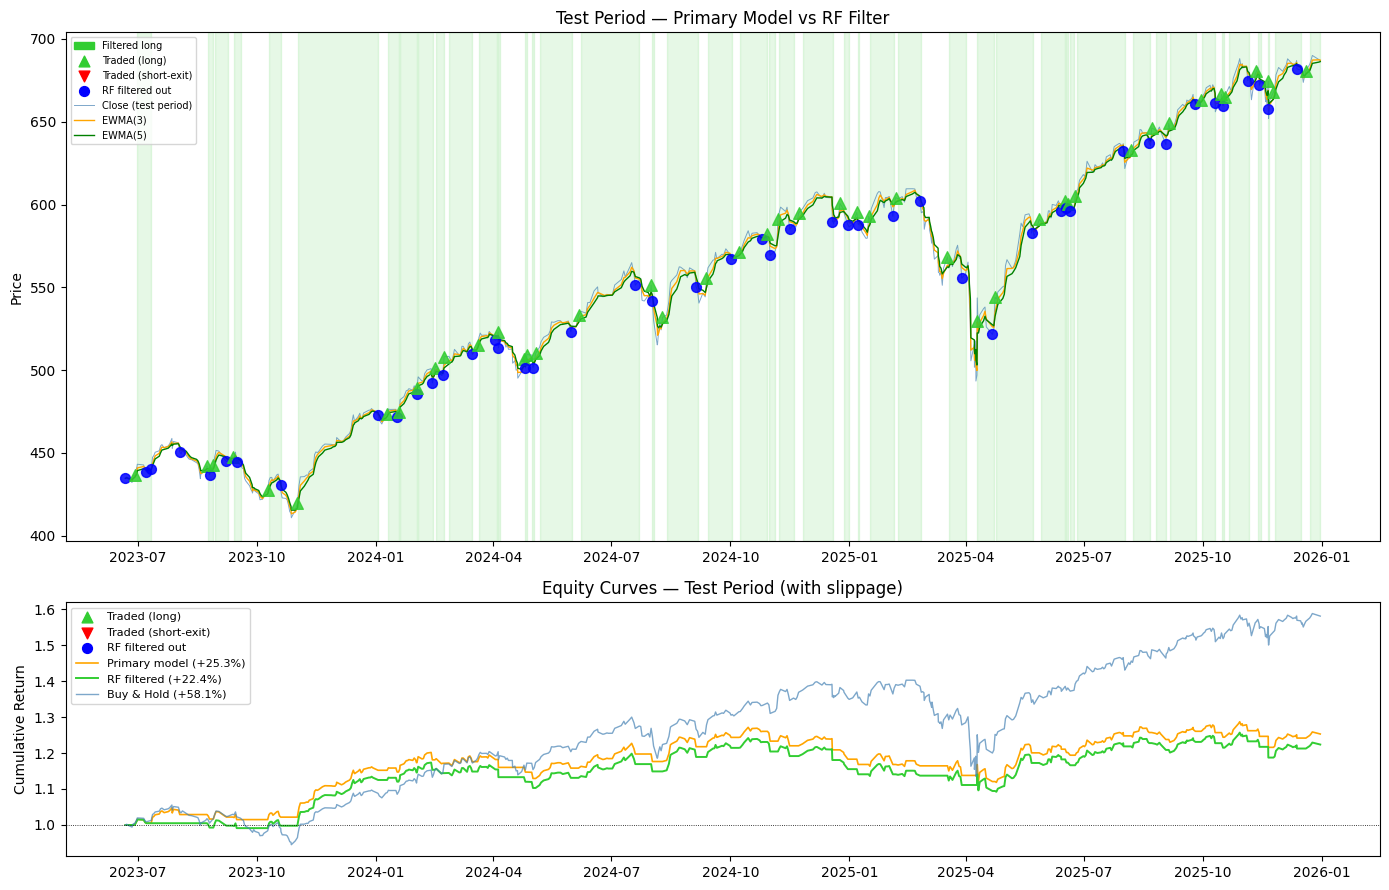

In [45]:
SLIPPAGE = 0#0.001  # 0.1% per trade (entry + exit)

# ── Helper: build a position series from an event signal series ───────────
def build_position(close_idx, signal_events: pd.Series) -> pd.Series:
    """
    Forward-fill a position series from event signals.

    signal_events : pd.Series indexed by event timestamps with values
                    +1 (long), -1 (exit to flat).
    Returns a bar-level position series (0 or 1), shifted 1 bar to avoid
    look-ahead.
    """
    sig = signal_events.reindex(close_idx).fillna(0)
    # Map: +1 -> 1 (enter long), -1 -> 0 (exit), 0 -> NaN (carry forward)
    marker = pd.Series(np.nan, index=close_idx)
    marker[sig ==  1] = 1.0
    marker[sig == -1] = 0.0
    pos = marker.ffill().fillna(0).astype(int)
    return pos.shift(1).fillna(0).astype(int)  # execute next bar


def summarize_strategy(name: str, pos: pd.Series, bar_returns: pd.Series) -> pd.Series:
    """Summarize a bar-level strategy and its trade distribution."""
    turnover = pos.diff().abs().fillna(pos.iloc[0]).astype(float)
    strat_bar_ret = pos * bar_returns - SLIPPAGE * turnover
    equity = (1 + strat_bar_ret).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    trade_group = (pos.ne(pos.shift())).cumsum()
    trade_returns = []
    for _, grp in strat_bar_ret.groupby(trade_group):
        if pos.loc[grp.index[0]] == 1:
            trade_returns.append((1 + grp).prod() - 1)
    trade_returns = pd.Series(trade_returns, dtype=float)
    n_trades = int(trade_returns.shape[0])
    win_rate = float((trade_returns > 0).mean()) if n_trades else np.nan
    avg_trade_return = float(trade_returns.mean()) if n_trades else np.nan
    median_trade_return = float(trade_returns.median()) if n_trades else np.nan
    profit_factor = np.nan
    if n_trades:
        gross_profit = trade_returns[trade_returns > 0].sum()
        gross_loss = -trade_returns[trade_returns < 0].sum()
        if gross_loss > 0:
            profit_factor = float(gross_profit / gross_loss)
    return pd.Series({
        'Total Return': float(equity.iloc[-1] - 1.0),
        'Max Drawdown': float(drawdown.min()),
        'Bar Mean Return': float(strat_bar_ret.mean()),
        'Bar Volatility': float(strat_bar_ret.std(ddof=0)),
        'Trades': n_trades,
        'Win Rate': win_rate,
        'Avg Trade Return': avg_trade_return,
        'Median Trade Return': median_trade_return,
        'Profit Factor': profit_factor,
        'Exposure': float(pos.mean()),
        'Trade Returns': trade_returns,
    }, name=name)


# ── Test-period price returns ─────────────────────────────────────────────
test_start = test_idx[0]
close_test = close[close.index >= test_start]
ret_test   = close_test.pct_change().fillna(0)

# ── 1. Primary model: take every crossover signal in the test period ───────
cross_test = events_cross.loc[events_cross.index >= test_start, 'side']
pos_all    = build_position(close_test.index, cross_test)

# ── 2. Filtered: only signals where RF predicts meta-label = 1 ───────────
# Build a combined signal: side if RF says trade, else replace with
# an explicit exit (-1) so the position returns to flat.
rf_decisions = pd.Series(y_pred_test, index=test_idx)
filtered_sig = cross_test.copy()
for ts in test_idx:
    if ts in filtered_sig.index:
        if rf_decisions.loc[ts] == 0:
            filtered_sig[ts] = -1  # force exit signal
pos_filt = build_position(close_test.index, filtered_sig)

# ── 3. Buy & hold benchmark ───────────────────────────────────────────────
pos_bh = pd.Series(1, index=close_test.index, dtype=int)

# ── Strategy stats ────────────────────────────────────────────────────────
primary_stats  = summarize_strategy('Primary model (always take trade)', pos_all,  ret_test)
filtered_stats = summarize_strategy('RF filtered', pos_filt, ret_test)
bh_stats       = summarize_strategy('Buy & Hold', pos_bh,    ret_test)

stats = pd.DataFrame([primary_stats, filtered_stats, bh_stats])
stats_to_show = stats.drop(columns=['Trade Returns'])

ret_all  = primary_stats['Total Return']
ret_filt = filtered_stats['Total Return']
ret_bh   = bh_stats['Total Return']

n_all  = int(primary_stats['Trades'])
n_filt = int(filtered_stats['Trades'])

print(stats_to_show.to_string(float_format=lambda x: f'{x:,.4f}'))
print()
print('Comparison vs primary model (always take trade):')
print(f"  RF filtered return delta: {(ret_filt - ret_all):+.2%}")
print(f"  RF filtered trade delta : {(n_filt - n_all):+d}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                         gridspec_kw={'height_ratios': [2, 1]})

ax = axes[0]
ax.plot(close_test.index, close_test, lw=0.7,
        color='steelblue', alpha=0.7, label='Close (test period)')

fast_t = close_test.ewm(span=FAST_SPAN, adjust=False).mean()
slow_t = close_test.ewm(span=SLOW_SPAN, adjust=False).mean()
ax.plot(fast_t.index, fast_t, lw=1.0, color='orange',
        label=f'EWMA({FAST_SPAN})')
ax.plot(slow_t.index, slow_t, lw=1.0, color='green',
        label=f'EWMA({SLOW_SPAN})')

# Shade filtered-long periods
in_long, start_long = False, None
for ts, p in pos_filt.items():
    if p == 1 and not in_long:
        start_long = ts
        in_long    = True
    elif p != 1 and in_long:
        ax.axvspan(start_long, ts, color='limegreen', alpha=0.12)
        in_long = False
if in_long:
    ax.axvspan(start_long, close_test.index[-1], color='limegreen', alpha=0.12)

# Mark events: circle=filtered-out, triangle=traded
for ts in test_idx:
    if ts not in close_test.index:
        continue
    p = close_test.loc[ts]
    traded = (rf_decisions.loc[ts] == 1)
    side_v = cross_test.loc[ts] if ts in cross_test.index else 0
    if traded:
        mk, col, sz = ('^' if side_v == 1 else 'v'), ('limegreen' if side_v == 1 else 'red'), 70
    else:
        mk, col, sz = 'o', 'blue', 50
    ax.scatter(ts, p, marker=mk, color=col, s=sz, zorder=6, alpha=0.85)

ax.legend(
    handles=[
        mpatches.Patch(color='limegreen', label='Filtered long'),
        plt.scatter([], [], marker='^', color='limegreen', s=60, label='Traded (long)'),
        plt.scatter([], [], marker='v', color='red', s=60, label='Traded (short-exit)'),
        plt.scatter([], [], marker='o',  color='blue',       s=50, label='RF filtered out'),
    ] + ax.get_legend_handles_labels()[0][:3],
    fontsize=7, loc='upper left'
 )
ax.set_title('Test Period — Primary Model vs RF Filter')
ax.set_ylabel('Price')

ax2 = axes[1]
ax2.plot((1 + pos_all * ret_test - SLIPPAGE * pos_all.diff().abs().fillna(pos_all.iloc[0]).astype(float)).cumprod().index,
         (1 + pos_all * ret_test - SLIPPAGE * pos_all.diff().abs().fillna(pos_all.iloc[0]).astype(float)).cumprod(),
         label=f'Primary model ({ret_all:+.1%})',
         color='orange', lw=1.2)
ax2.plot((1 + pos_filt * ret_test - SLIPPAGE * pos_filt.diff().abs().fillna(pos_filt.iloc[0]).astype(float)).cumprod().index,
         (1 + pos_filt * ret_test - SLIPPAGE * pos_filt.diff().abs().fillna(pos_filt.iloc[0]).astype(float)).cumprod(),
         label=f'RF filtered ({ret_filt:+.1%})',
         color='limegreen', lw=1.4)
ax2.plot((1 + pos_bh * ret_test - SLIPPAGE * pos_bh.diff().abs().fillna(pos_bh.iloc[0]).astype(float)).cumprod().index,
         (1 + pos_bh * ret_test - SLIPPAGE * pos_bh.diff().abs().fillna(pos_bh.iloc[0]).astype(float)).cumprod(),
         label=f'Buy & Hold ({ret_bh:+.1%})',
         color='steelblue', lw=1.0, alpha=0.7)
ax2.axhline(1.0, color='black', lw=0.6, ls=':')
ax2.set_title('Equity Curves — Test Period (with slippage)')
ax2.set_ylabel('Cumulative Return')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Red-team critique

| Risk | Description |
|------|-------------|
| **Small event count** | EWMA crossovers are infrequent; the RF trains on O(100) events. With ≤ 9 features and `max_depth=4`, the model capacity is intentionally limited but overfitting remains a concern. A permutation test on the meta-label F1 is recommended. |
| **Feature–label correlation** | `side` (the EWMA direction) is both a feature and embedded in the meta-label definition. It is included deliberately — the RF should learn *when* the side is reliable — but it inflates apparent feature importance. |
| **Non-stationarity** | Features such as `bb_pct` and `rsi_14` are mean-reverting by construction; their predictive relationship with the meta-label may shift across regimes. |
| **No transaction costs** | Each filtered-in signal still incurs a round-trip cost; the filtered curve's advantage narrows under realistic cost assumptions. |
| **Single train/test split** | A single 70/30 split does not characterize estimation variance. A proper combinatorial purged cross-validation (CPCV, *AFML* §12) would be needed for thesis-grade inference. |
